If any of your imports aren't working use the cell below with the command %pip install (package)

In [5]:
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In this file we examine using linear regression as a machine learning model. 
Linear regression finds a line of best fit to predict outcomes. 
Just like in the sciences, our line of best fit will be based on a dependent variable (the y axis), and an independent variable(s) (the x axis).

To achieve our goal of using linear regression we will require the following imports

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from pandas.core.common import random_state

In this example we will use random data points that loosely follow a straight line

In [ ]:
np.random.seed(42)

X = np.random.rand(50, 1) * 100  

Y = 3.5 * X + np.random.randn(50, 1) * 20 

[[37.45401188]
 [95.07143064]
 [73.19939418]
 [59.86584842]
 [15.60186404]
 [15.59945203]
 [ 5.80836122]
 [86.61761458]
 [60.11150117]
 [70.80725778]
 [ 2.05844943]
 [96.99098522]
 [83.24426408]
 [21.23391107]
 [18.18249672]
 [18.34045099]
 [30.4242243 ]
 [52.47564316]
 [43.19450186]
 [29.12291402]
 [61.18528947]
 [13.94938607]
 [29.21446485]
 [36.63618433]
 [45.60699842]
 [78.51759614]
 [19.96737822]
 [51.42344384]
 [59.24145689]
 [ 4.64504127]
 [60.75448519]
 [17.05241237]
 [ 6.5051593 ]
 [94.88855373]
 [96.56320331]
 [80.83973481]
 [30.46137692]
 [ 9.7672114 ]
 [68.42330265]
 [44.01524937]
 [12.20382348]
 [49.51769101]
 [ 3.43885211]
 [90.93204021]
 [25.87799816]
 [66.25222844]
 [31.17110761]
 [52.00680212]
 [54.67102793]
 [18.48544555]]


Here we define our model as using linear regression and fit it to the data we have provided

In [3]:
model = LinearRegression()
model.fit(X, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Our prediction below establishes the y values for the line of best fit

In [46]:
Y_pred = model.predict(X)

Here we are just making a graph using the data we have created as a scatter plot (dots) and our line of best fit to compare the two

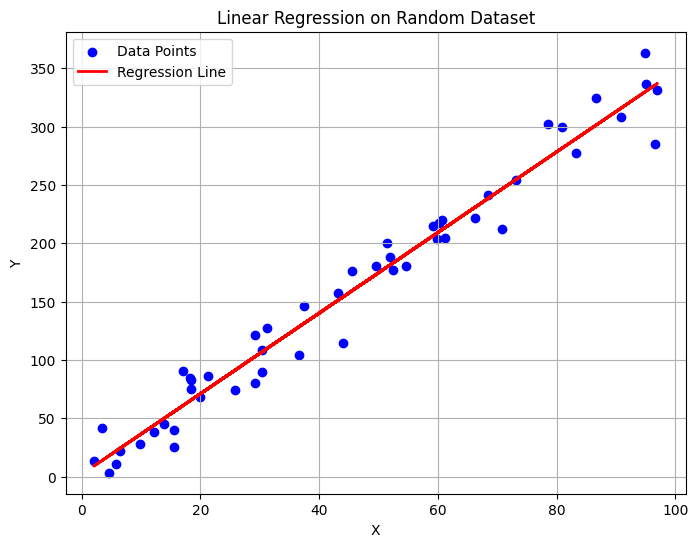

In [47]:
plt.figure(figsize=(8,6)) 
plt.scatter(X, Y, color='blue', label='Data Points') 
plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line') 
plt.title('Linear Regression on Random Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

We can also retrieve the coefficient and intercept values to see what they are

In [6]:
print("Slope (Coefficient):", model.coef_[0][0])
print("Intercept:", model.intercept_[0])

Slope (Coefficient): 3.4553132007706204
Intercept: 1.9337854893777546


Now we can make predictions using our line of best fit. Below I have predicted what y value we should have at x = 60

In [7]:
print(model.predict([[60]]))

[[209.25257754]]


If we look at the graph we can see that it looks about right

We can further determine the fit of the line by examining the r squared value (coefficient of determination). The closer to 1 it is the better fit a line is

In [8]:
r2 = r2_score(Y, model.predict(X))

print(r2)

0.9673825411815328


With a dataset, we can split it up into training and testing data in which we can find the r2 value for both to determine whether this is a good model.

To use and manipulate datasets in Python, we use the pandas library (no I don't know why it's called that) 

In [9]:
import pandas as pd

Here we are reading our dataset and displaying the columns and the first few rows (by the way, df stands for dataframe)

In [20]:
df = pd.read_csv('Salary_dataset.csv')
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


Let's plot the data to get an idea of its shape

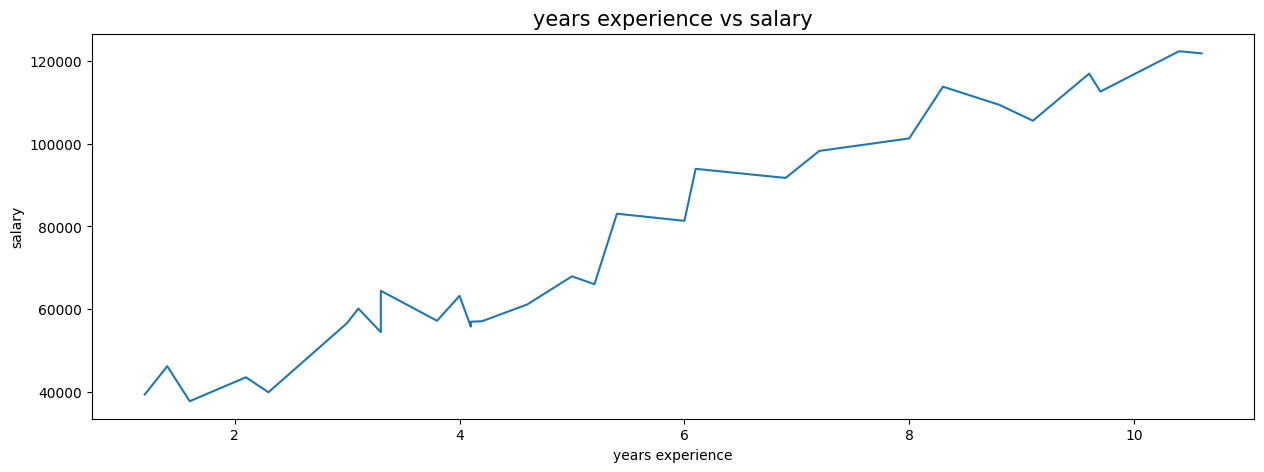

In [16]:
plt.figure(figsize=(15,5))
plt.plot(df.get('YearsExperience'), df.get('Salary'))
plt.title('years experience vs salary', fontsize=15)
plt.ylabel('salary')
plt.xlabel('years experience')
plt.show()

With such a simple dataset we don't need to change, add or remove any columns so we can just split it into training and testing data.

In [83]:
x = df.iloc[1]  # independent
y = df.iloc[:, :2]  # dependent
print(x)
print(y)
#this is the python built in split - this is less useful with more columns
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
lin_model = LinearRegression()
lin_model.fit(x_train, y_train)

Unnamed: 0             1.0
YearsExperience        1.4
Salary             46206.0
Name: 1, dtype: float64
    Unnamed: 0  YearsExperience
0            0              1.2
1            1              1.4
2            2              1.6
3            3              2.1
4            4              2.3
5            5              3.0
6            6              3.1
7            7              3.3
8            8              3.3
9            9              3.8
10          10              4.0
11          11              4.1
12          12              4.1
13          13              4.2
14          14              4.6
15          15              5.0
16          16              5.2
17          17              5.4
18          18              6.0
19          19              6.1
20          20              6.9
21          21              7.2
22          22              8.0
23          23              8.3
24          24              8.8
25          25              9.1
26          26              9.6

ValueError: Found input variables with inconsistent numbers of samples: [3, 30]

In [ ]:
r2_2 = r2_score(train_y, model.predict(x))

print(r2_2)

ValueError: X has 30 features, but LinearRegression is expecting 1 features as input.

[[ 39344.  46206.  37732.  43526.  39892.  56643.  60151.  54446.  64446.
   57190.  63219.  55795.  56958.  57082.  61112.  67939.  66030.  83089.
   81364.  93941.  91739.  98274. 101303. 113813. 109432. 105583. 116970.
  112636. 122392. 121873.]]


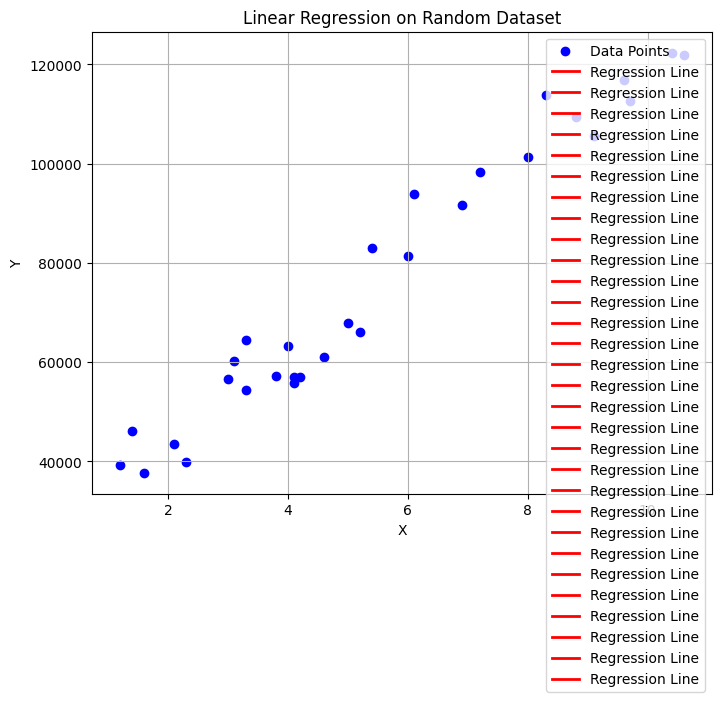

In [60]:
y_pred = lin_model.predict(x)
print(y_pred)
plt.figure(figsize=(8,6)) 
plt.scatter(x, y, color='blue', label='Data Points') 
plt.plot(x, y_pred, color='red', linewidth=2, label='Regression Line') 
plt.title('Linear Regression on Random Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()